In [1]:
import FinanceDataReader as fdr
import numpy as np
import matplotlib.pyplot as plt


In [2]:
samsung = fdr.DataReader('005930', '2020')

In [3]:
print(samsung.head())

             Open   High    Low  Close    Volume    Change
Date                                                      
2020-01-02  55500  56000  55000  55200  12993228 -0.010753
2020-01-03  56000  56600  54900  55500  15422255  0.005435
2020-01-06  54900  55600  54600  55500  10278951  0.000000
2020-01-07  55700  56400  55600  55800  10009778  0.005405
2020-01-08  56200  57400  55900  56800  23501171  0.017921


In [4]:
print(samsung.tail())

              Open    High     Low   Close    Volume    Change
Date                                                          
2026-06-24  314000  341000  314000  340500  47809959  0.098387
2026-06-25  359500  362500  352000  358500  36157158  0.052863
2026-06-26  354000  356500  321500  339500  39735951 -0.052999
2026-06-29  331000  335500  316000  323000  35436521 -0.048601
2026-06-30  323500  335500  321000  329250  11416856  0.019350


In [5]:
samsung['Open']

Date
2020-01-02     55500
2020-01-03     56000
2020-01-06     54900
2020-01-07     55700
2020-01-08     56200
               ...  
2026-06-24    314000
2026-06-25    359500
2026-06-26    354000
2026-06-29    331000
2026-06-30    323500
Name: Open, Length: 1593, dtype: int64

In [6]:
seq_data = (samsung[['Open']]).to_numpy()

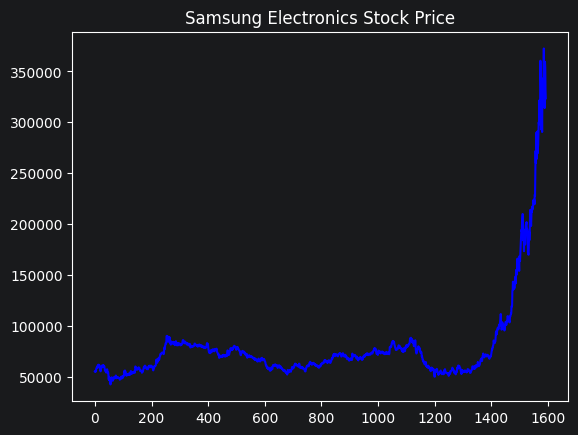

In [7]:
plt.plot(seq_data, color='blue')
plt.title("Samsung Electronics Stock Price")
plt.xlabel("days")
plt.xlabel("")
plt.show()

In [8]:
print(seq_data.shape)

(1593, 1)


In [9]:
from sklearn.preprocessing import MinMaxScaler

In [10]:
scaler = MinMaxScaler(feature_range = (0, 1))

In [11]:
samsung = fdr.DataReader('005930','2016')

In [12]:
open_values = samsung[['Open']]

In [13]:
print(open_values.tail())

              Open
Date              
2026-06-24  314000
2026-06-25  359500
2026-06-26  354000
2026-06-29  331000
2026-06-30  323500


In [14]:
scaler = MinMaxScaler(feature_range = (0, 1))
scaled = scaler.fit_transform(open_values)

In [15]:
# TEST_SIZE = 200
# train_data = scaled[: - TEST_SIZE]
# test_data = scaled[ -TEST_SIZE:]

In [16]:
def make_sample(data, window):
    train = []
    target = []
    for i in range(len(data) - window):
        train.append(data[i:i+window])
        target.append(data[i+window])
    return np.array(train), np.array(target)
# X_train, y_train = make_sample(train_data, 30)

In [17]:
TEST_SIZE = 1000
train_data = scaled[: - TEST_SIZE]
test_data = scaled[ -TEST_SIZE:]

In [18]:
X_train, y_train = make_sample(train_data, 40)

In [19]:
print(X_train.shape)
print(y_train.shape)

(1532, 40, 1)
(1532, 1)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM


In [21]:
model = Sequential()
model.add(LSTM(16, input_shape=(X_train.shape[1], 1), activation='tanh', return_sequences=False))
model.add(Dense(1))

C:\Users\KOREA_HRD_1_3\PycharmProjects\study\ML\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
model.compile(loss='mse', optimizer='adam')

In [23]:
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0044
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.0559e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.1350e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1543e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.1694e-05
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.4525e-05
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.4291e-05
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.6738e-05
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.4819e-05
Epoch 10/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.1193e-05
Epoch 11/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.1913e-05
Epoch 12/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.1658e-05
Epoch 13/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9459e-05
Epoch 14/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.8742e-05
Epoch 15/100
48/48 

In [24]:
(X_test, y_test) = make_sample(test_data, 40)

In [25]:
model.evaluate(X_test, y_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6986e-04


0.0002698601165320724

In [26]:
y_predict = model.predict(X_test)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [27]:
import matplotlib.pyplot as plt

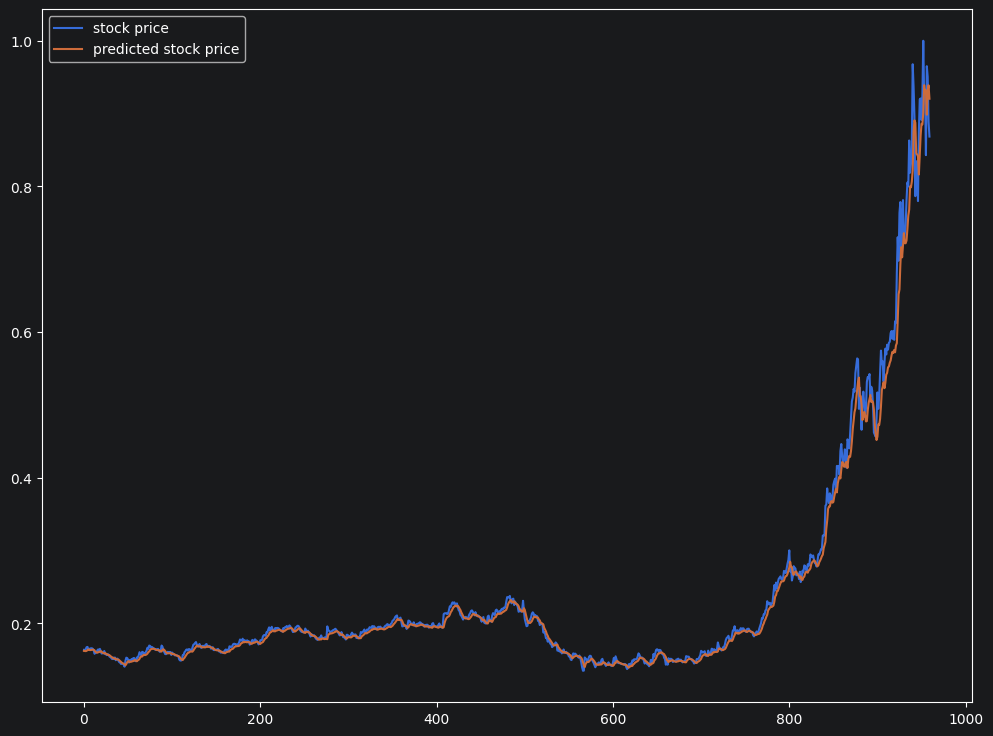

In [28]:
plt.figure(figsize=(12, 9))
plt.plot(y_test, label='stock price')
plt.plot(y_predict, label='predicted stock price')
plt.legend()
plt.show()